Caricare tutti i file JSON della cartella locale su HDFS

In [1]:
!hdfs dfs -put -f  /Users/margheritasantarossa/Desktop/CVE/datasets/nvd/*.json /hdfs_dir/

2025-10-04 15:09:15,633 WARN util.NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Verificare che i file siano effettivamente caricati su HDFS

In [15]:
!hdfs dfs -ls /hdfs_dir/

2025-10-04 14:47:07,043 WARN util.NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
Found 11 items
-rw-r--r--   1 margheritasantarossa supergroup   52514299 2025-10-04 12:47 /hdfs_dir/nvdcve-2.0-2015.json
-rw-r--r--   1 margheritasantarossa supergroup   66078415 2025-10-04 12:47 /hdfs_dir/nvdcve-2.0-2016.json
-rw-r--r--   1 margheritasantarossa supergroup   93883549 2025-10-04 12:47 /hdfs_dir/nvdcve-2.0-2017.json
-rw-r--r--   1 margheritasantarossa supergroup   98708455 2025-10-04 12:47 /hdfs_dir/nvdcve-2.0-2018.json
-rw-r--r--   1 margheritasantarossa supergroup  111356146 2025-10-04 12:47 /hdfs_dir/nvdcve-2.0-2019.json
-rw-r--r--   1 margheritasantarossa supergroup  146390647 2025-10-04 12:47 /hdfs_dir/nvdcve-2.0-2020.json
-rw-r--r--   1 margheritasantarossa supergroup  174250873 2025-10-04 12:47 /hdfs_dir/nvdcve-2.0-2021.json
-rw-r--r--   1 margheritasantarossa supergroup  173719863 2025-10-04 12:47 /hdfs_dir/nvdc

In [15]:
# Se sei in notebook con cella magica
!pip install matplotlib pandas

  Using cached numpy-2.3.3-cp313-cp313-macosx_14_0_arm64.whl.metadata (62 kB)
  Using cached pytz-2025.2-py2.py3-none-any.whl.metadata (22 kB)
  Using cached tzdata-2025.2-py2.py3-none-any.whl.metadata (1.4 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 8.8 MB/s  0:00:00 eta 0:00:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 6.7 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 8.6 MB/s  0:00:00 eta 0:00:01
Using cached numpy-2.3.3-cp313-cp313-macosx_14_0_arm64.whl (5.1 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 11.5 MB/s  0:00:00 eta 0:00:01
Using cached pytz-2025.2-py2.py3-none-any.whl (509 kB)
Using cached tzdata-2025.2-py2.py3-none-any.whl (347 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11/11 [matplotlib]1 [matplotlib]


In [37]:
pip install scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 15.0 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.9/20.9 MB 15.7 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [scikit-learn] [scikit-learn]
Note: you may need to restart the kernel to use updated packages.


In [32]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, explode

# Crea/ricrea la sessione Spark con più memoria driver se serve
spark = SparkSession.builder \
        .appName("CVE_Analysis_Safe") \
        .config("spark.driver.memory", "4g") \
        .getOrCreate()

# Percorso del file JSON su HDFS
hdfs_file = "hdfs://localhost:9000/hdfs_dir/*.json"

# Leggi il file in modalità multiLine
df_raw = spark.read.option("multiLine", "true").json(hdfs_file)

df_raw.printSchema()
print(df_raw.count())
df_raw.select("version").distinct().show()

# Mostra solo il primo record
#df_selected.limit(1).show(truncate=False)

root
 |-- format: string (nullable = true)
 |-- resultsPerPage: long (nullable = true)
 |-- startIndex: long (nullable = true)
 |-- timestamp: string (nullable = true)
 |-- totalResults: long (nullable = true)
 |-- version: string (nullable = true)
 |-- vulnerabilities: array (nullable = true)
 |    |-- element: struct (containsNull = true)
 |    |    |-- cve: struct (nullable = true)
 |    |    |    |-- cisaActionDue: string (nullable = true)
 |    |    |    |-- cisaExploitAdd: string (nullable = true)
 |    |    |    |-- cisaRequiredAction: string (nullable = true)
 |    |    |    |-- cisaVulnerabilityName: string (nullable = true)
 |    |    |    |-- configurations: array (nullable = true)
 |    |    |    |    |-- element: struct (containsNull = true)
 |    |    |    |    |    |-- nodes: array (nullable = true)
 |    |    |    |    |    |    |-- element: struct (containsNull = true)
 |    |    |    |    |    |    |    |-- cpeMatch: array (nullable = true)
 |    |    |    |    |    |

In [33]:
from pyspark.sql import functions as F

# 1️⃣ Esplodi l’array delle vulnerabilità
df_exploded = df_raw.select(F.explode("vulnerabilities").alias("vuln"))

# 2️⃣ Estrai i campi principali
df_cve = df_exploded.select(
    F.col("vuln.cve.id").alias("cve_id"),
    F.expr("filter(vuln.cve.descriptions, x -> x.lang = 'en')[0].value").alias("description"),
    F.col("vuln.cve.published").alias("published"),
    F.col("vuln.cve.metrics.cvssMetricV31")[0].alias("cvss")  # versione più recente e standard
)

# 3️⃣ Estrai punteggio e severità CVSS
df_cve = df_cve.select(
    "cve_id",
    "description",
    "published",
    F.col("cvss.cvssData.baseScore").alias("baseScore"),
    F.col("cvss.cvssData.baseSeverity").alias("severity")
)

# 4️⃣ Aggiungi la colonna “anno” estratta dalla data di pubblicazione
df_cve = df_cve.withColumn("year", F.substring(F.col("published"), 1, 4))

# 5️⃣ Rimuovi CVE senza severità
df_cve_filtered = df_cve.filter(F.col("severity").isNotNull())

# ✅ Controlla un campione
df_cve_filtered.show(5, truncate=False)
print("Totale CVE con severità:", df_cve_filtered.count())

+--------------+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+-----------------------+---------+--------+----+
|cve_id        |description                                                                                                                                                                                                                                                                                                                                                                                                                                      

[Stage 98:=======================================>                 (7 + 3) / 10]

Totale CVE con severità: 169724


In [34]:
df_grouped = df_cve_filtered.groupBy("year", "severity").count().orderBy("year")
df_grouped.show()

[Stage 101:============================================>           (8 + 2) / 10]

+----+--------+-----+
|year|severity|count|
+----+--------+-----+
|2015|  MEDIUM|    9|
|2015|    HIGH|   41|
|2015|CRITICAL|   24|
|2016|     LOW|    7|
|2016|  MEDIUM|  201|
|2016|CRITICAL|   92|
|2016|    HIGH|  466|
|2017|CRITICAL|  271|
|2017|     LOW|   22|
|2017|  MEDIUM|  564|
|2017|    HIGH|  785|
|2018|  MEDIUM|  611|
|2018|    HIGH|  844|
|2018|CRITICAL|  319|
|2018|     LOW|   21|
|2019|     LOW|  191|
|2019|  MEDIUM| 3617|
|2019|    HIGH| 3620|
|2019|CRITICAL| 1174|
|2020|CRITICAL| 2450|
+----+--------+-----+
only showing top 20 rows



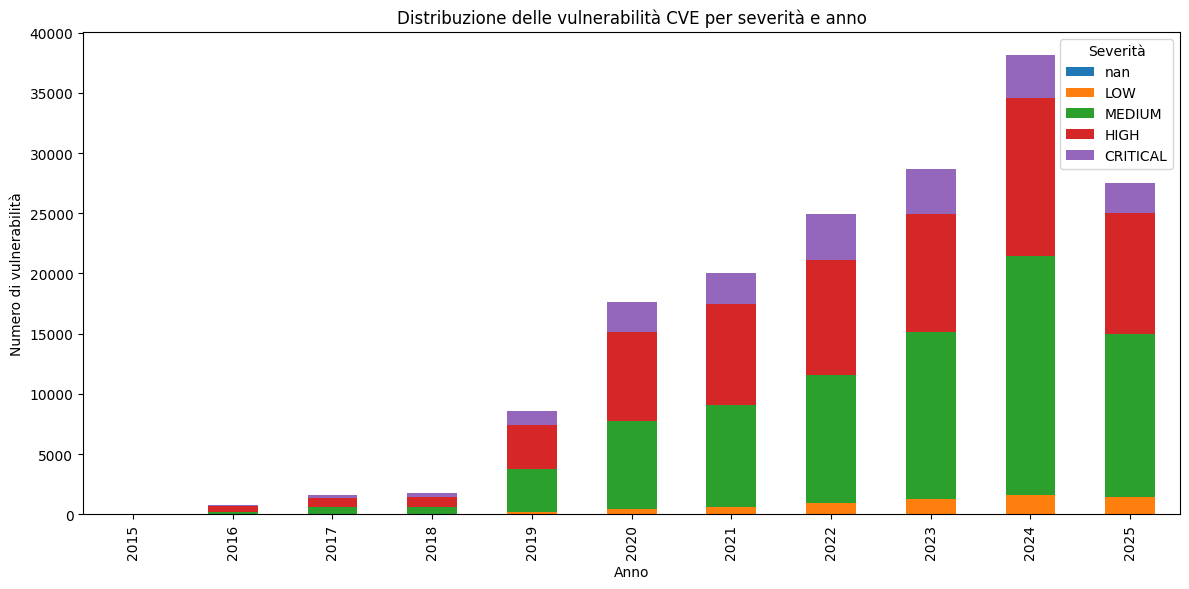

In [35]:
import pandas as pd
import matplotlib.pyplot as plt

# Raggruppa per anno e severità
df_grouped = df_cve_filtered.groupBy("year", "severity").count().orderBy("year")

# Converti in pandas per il plotting
pdf = df_grouped.toPandas()

# Ordina le categorie di severità
severity_order = ["LOW", "MEDIUM", "HIGH", "CRITICAL"]
pdf["severity"] = pd.Categorical(pdf["severity"], categories=severity_order, ordered=True)

# Pivot per grafico
pdf_pivot = pdf.pivot(index="year", columns="severity", values="count").fillna(0)

# Plot stacked bar chart
pdf_pivot.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6)
)

plt.title("Distribuzione delle vulnerabilità CVE per severità e anno")
plt.xlabel("Anno")
plt.ylabel("Numero di vulnerabilità")
plt.legend(title="Severità")
plt.tight_layout()
plt.show()

🔮 Stima CVE 2025: 34,760
🔮 Stima CVE 2026: 38,627


/Users/margheritasantarossa/spark-env/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


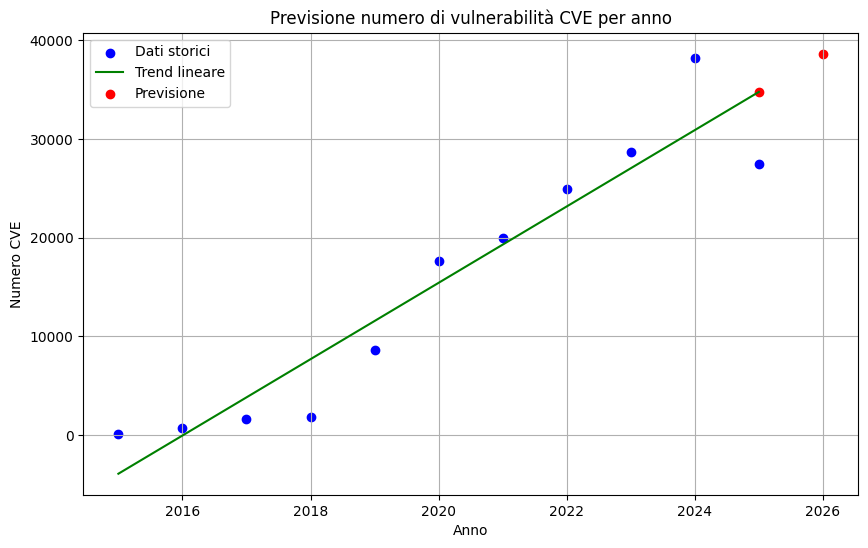

In [39]:
#LINEAR REGRESSION TO PREDICT THE NUMBER OF VULNERABILITIES FOR 2025 AND 2026
import pandas as pd
from sklearn.linear_model import LinearRegression
import numpy as np
import matplotlib.pyplot as plt

# Aggrega per anno
df_year = df_cve_filtered.groupBy("year").count().orderBy("year").toPandas()

# Rimuovi eventuali righe con year non numerico
df_year = df_year[df_year["year"].astype(str).str.isnumeric()]
df_year["year"] = df_year["year"].astype(int)

# Prepara i dati per la regressione
X = df_year[["year"]]
y = df_year["count"]

# Crea e allena il modello
model = LinearRegression()
model.fit(X, y)

# Prevedi per 2025 e 2026
future_years = np.array([[2025], [2026]])
future_preds = model.predict(future_years)

# Mostra i risultati
for year, pred in zip(future_years.flatten(), future_preds):
    print(f"🔮 Stima CVE {year}: {int(pred):,}")

# Grafico del trend + previsioni
plt.figure(figsize=(10,6))
plt.scatter(df_year["year"], df_year["count"], color="blue", label="Dati storici")
plt.plot(df_year["year"], model.predict(X), color="green", label="Trend lineare")
plt.scatter(future_years, future_preds, color="red", label="Previsione")
plt.xlabel("Anno")
plt.ylabel("Numero CVE")
plt.title("Previsione numero di vulnerabilità CVE per anno")
plt.legend()
plt.grid(True)
plt.show()